In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler


In [2]:
data1 = pd.read_csv('engine_fault_detection_dataset.csv') #read csv data

print(data1.head()) # shows first few rows of data

   Vibration_Amplitude  RMS_Vibration  Vibration_Frequency  \
0             3.807947       1.899522          1465.396656   
1             9.512072       1.697915           385.333751   
2             7.346740       0.921962           706.346595   
3             6.026719       3.055970          1333.295661   
4             1.644585       2.409290           974.536902   

   Surface_Temperature  Exhaust_Temperature  Acoustic_dB  Acoustic_Frequency  \
0           106.577348           319.564816   110.834195         3733.620495   
1            85.115094           237.927110    89.671023         4417.399188   
2           145.739823           250.543690    71.727937         2369.581389   
3            56.277414           272.268451   104.198507         1516.975785   
4           100.542770           281.461334    85.120688         1662.348214   

   Intake_Pressure  Exhaust_Pressure  Frequency_Band_Energy  Amplitude_Mean  \
0        91.279833        104.544934               0.889443        

In [3]:
cols = ['unit', 'cycle', 'op_1', 'op_2', 'op_3',
        'T2','T24','T30','T50','P2','P15','P30','Nf','Nc','epr',
        'Ps30','phi','NRf','NRc','BPR','farB','htBleed',
        'Nf_dmd','PCNfR_dmd','W31','W32']

dfs = []
for fd, offset in [('FD001',0), ('FD002',100), ('FD003',360), ('FD004',460)]:
    df = pd.read_csv(f'CMAPSSData/train_{fd}.txt', sep=r'\s+', header=None, names=cols)
    df['unit'] = df['unit'] + offset  # avoid duplicate unit IDs across datasets
    df['dataset'] = fd
    dfs.append(df)

df_cmapss = pd.concat(dfs, ignore_index=True)
print(df_cmapss.head())

   unit  cycle    op_1    op_2   op_3      T2     T24      T30      T50  \
0     1      1 -0.0007 -0.0004  100.0  518.67  641.82  1589.70  1400.60   
1     1      2  0.0019 -0.0003  100.0  518.67  642.15  1591.82  1403.14   
2     1      3 -0.0043  0.0003  100.0  518.67  642.35  1587.99  1404.20   
3     1      4  0.0007  0.0000  100.0  518.67  642.35  1582.79  1401.87   
4     1      5 -0.0019 -0.0002  100.0  518.67  642.37  1582.85  1406.22   

      P2  ...      NRf      NRc     BPR  farB  htBleed  Nf_dmd  PCNfR_dmd  \
0  14.62  ...  2388.02  8138.62  8.4195  0.03      392    2388      100.0   
1  14.62  ...  2388.07  8131.49  8.4318  0.03      392    2388      100.0   
2  14.62  ...  2388.03  8133.23  8.4178  0.03      390    2388      100.0   
3  14.62  ...  2388.08  8133.83  8.3682  0.03      392    2388      100.0   
4  14.62  ...  2388.04  8133.80  8.4294  0.03      393    2388      100.0   

     W31      W32  dataset  
0  39.06  23.4190    FD001  
1  39.00  23.4236    FD001  

In [4]:
#find number of cycles and calculate number of cycles to failure
df_cmapss['max_cycle'] = df_cmapss.groupby('unit')['cycle'].transform('max')
df_cmapss['RUL'] = df_cmapss['max_cycle'] - df_cmapss['cycle']

df_cmapss['Engine_Condition'] = 0
df_cmapss.loc[df_cmapss['RUL'] <= 25, 'Engine_Condition'] = 1 #tune for better accuracy (current threshold is 25 cycles to failure)
df_cmapss.loc[df_cmapss['RUL'] <= 10, 'Engine_Condition'] = 2 #tune for better accuracy (current threshold is 10 cycles to failure)

In [5]:
#Match column names:
df_mapped = pd.DataFrame({
    'Surface_Temperature': df_cmapss['T30'],   # HPC outlet temp
    'Exhaust_Temperature': df_cmapss['T50'],   # LPT outlet temp
    'Intake_Pressure':     df_cmapss['P30'],   # HPC outlet pressure
    'Exhaust_Pressure':    df_cmapss['Ps30'],  # static pressure at HPC
    'Engine_Condition':    df_cmapss['Engine_Condition'].values,
})

In [6]:
feature_cols = ['Surface_Temperature', 'Exhaust_Temperature', 
                'Intake_Pressure', 'Exhaust_Pressure']

#scale the data so that the range of data is normal and doesnt flag an immediate fault
scaler_csv    = MinMaxScaler()
scaler_cmapss = MinMaxScaler()

csv_scaled    = scaler_csv.fit_transform(data1[feature_cols])
cmapss_scaled = scaler_cmapss.fit_transform(df_mapped[feature_cols])

df_csv_scaled = pd.DataFrame(csv_scaled, columns=feature_cols)
df_csv_scaled['Engine_Condition'] = data1['Engine_Condition'].values
df_csv_scaled['source'] = 'FaultCSV'

df_cmapss_scaled = pd.DataFrame(cmapss_scaled, columns=feature_cols)
df_cmapss_scaled['Engine_Condition'] = df_mapped['Engine_Condition'].values
df_cmapss_scaled['source'] = 'CMAPSS'


In [7]:
#combine data and randomly organise it so train and test do not favour certain datasets
df_combined = pd.concat([df_csv_scaled, df_cmapss_scaled], ignore_index=True)
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_combined.shape)
print(df_combined['Engine_Condition'].value_counts())
print(df_combined.head())

(170359, 6)
Engine_Condition
0    147888
1     13672
2      8799
Name: count, dtype: int64
   Surface_Temperature  Exhaust_Temperature  Intake_Pressure  \
0             0.906317             0.905870         0.960680   
1             0.925983             0.907689         0.961370   
2             0.941642             0.925045         0.957229   
3             0.257963             0.200876         0.005752   
4             0.664814             0.653907         0.591593   

   Exhaust_Pressure  Engine_Condition  source  
0          0.879103                 0  CMAPSS  
1          0.911129                 0  CMAPSS  
2          0.943155                 1  CMAPSS  
3          0.465172                 0  CMAPSS  
4          0.706966                 0  CMAPSS  


In [8]:
import matplotlib.pyplot as plt
import matplotlib

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

# Reproducibility seed
SEED = 42

x = df_combined.drop(["Engine_Condition", "source"], axis=1)

y = df_combined["Engine_Condition"]

xTrain, xTest, yTrain, yTest = train_test_split(x,y, train_size=0.75, random_state=10)

#majority of data is no fault (need more severe faults). Apply SMOTE to generate new synthetic data points
smote = SMOTE(random_state=SEED)
xTrain1, yTrain1 = smote.fit_resample(xTrain, yTrain) #resample data

pd.Series(yTrain1).value_counts()


Engine_Condition
0    110938
2    110938
1    110938
Name: count, dtype: int64

In [9]:
# Train a default (unconstrained) Decision Tree
dt_default = DecisionTreeClassifier(random_state=SEED)
dt_default.fit(xTrain1, yTrain1)

y_pred_default = dt_default.predict(xTest)
print(f'Default DT accuracy: {accuracy_score(yTest, y_pred_default):.4f}')
print(f'Default DT max depth: {dt_default.get_depth()}')

Default DT accuracy: 0.8666
Default DT max depth: 39


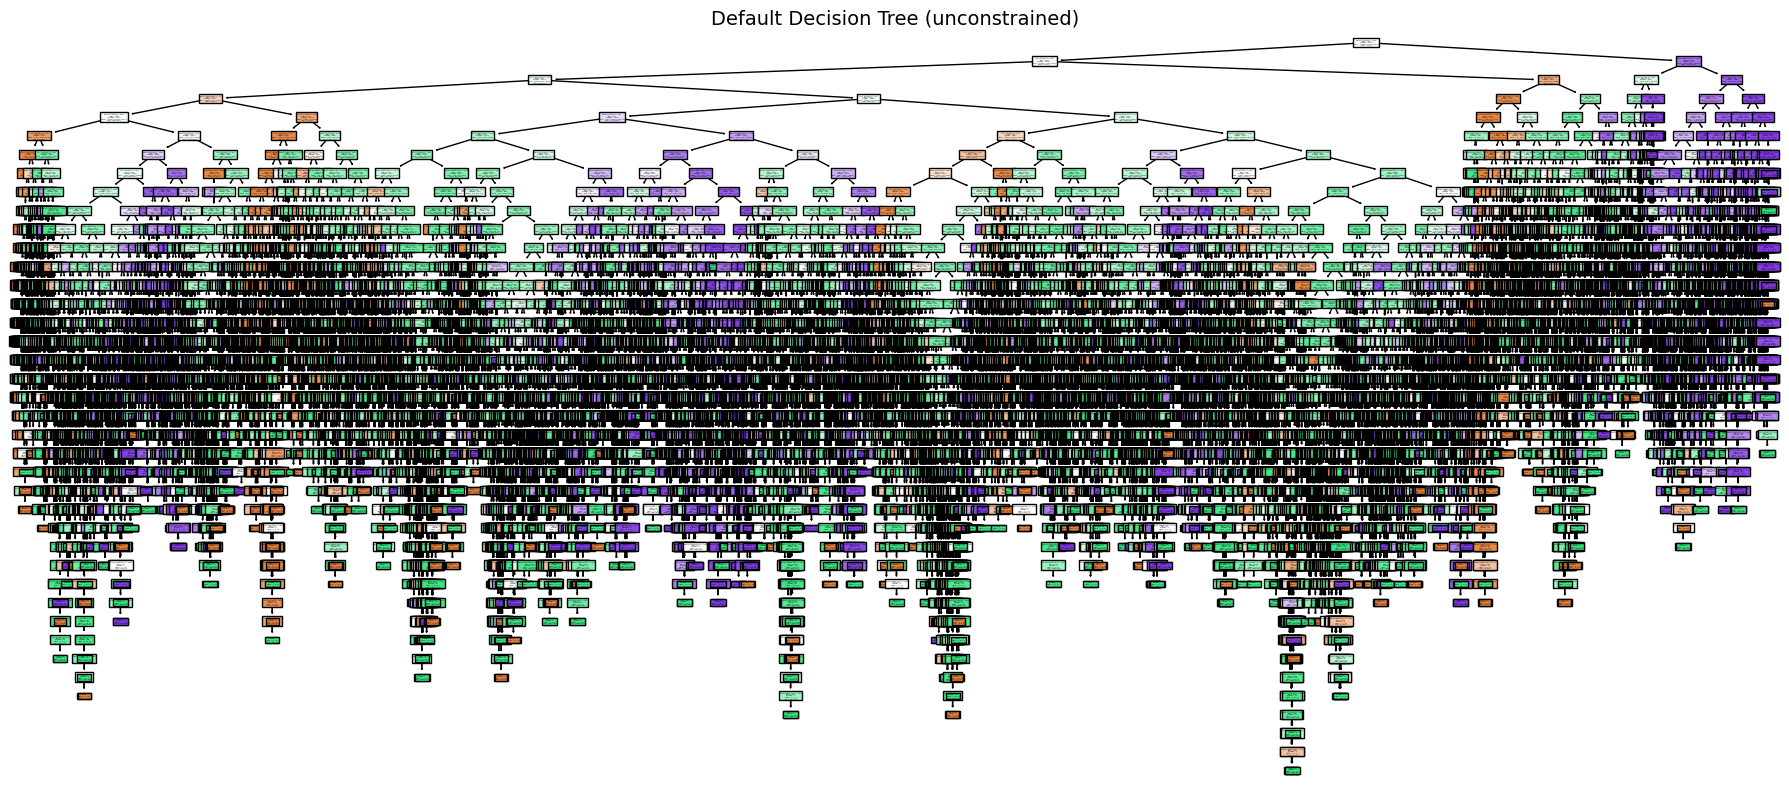

|--- Exhaust_Pressure <= 0.95
|   |--- Intake_Pressure <= 0.96
|   |   |--- Exhaust_Temperature <= 0.26
|   |   |   |--- Exhaust_Temperature <= 0.20
|   |   |   |   |--- Exhaust_Pressure <= 0.07
|   |   |   |   |   |--- Intake_Pressure <= 0.09
|   |   |   |   |   |   |--- Exhaust_Temperature <= 0.07
|   |   |   |   |   |   |   |--- Exhaust_Pressure <= 0.06
|   |   |   |   |   |   |   |   |--- Intake_Pressure <= 0.07
|   |   |   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |   |   |--- Intake_Pressure >  0.07
|   |   |   |   |   |   |   |   |   |--- Intake_Pressure <= 0.09
|   |   |   |   |   |   |   |   |   |   |--- Exhaust_Pressure <= 0.06
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |   |   |   |   |   |   |--- Exhaust_Pressure >  0.06
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 15
|   |   |   |   |   |   |   |   |   |--- Intake_Pressure >  0.09
|   |   |   |   |   |   |   |   |   |   |--

In [18]:
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(
dt_default,
feature_names=x.columns.tolist(),
class_names=['No Fault', 'Minor Fault', 'Severe Fault'],
filled=True,
ax=ax
)
plt.title('Default Decision Tree (unconstrained)', fontsize=14)
plt.tight_layout()
plt.show()

print(export_text(dt_default, feature_names=x.columns.tolist()))

max_depth  train_acc  test_acc
        1   0.428597  0.879596
        2   0.476494  0.361470
        3   0.550019  0.658464
        4   0.585243  0.555764
        5   0.678890  0.790843
        6   0.710280  0.788824
        7   0.727806  0.801620
        8   0.766086  0.839258
        9   0.791523  0.839305
       10   0.805645  0.848650
       11   0.818073  0.845527
       12   0.834436  0.852829
       13   0.850382  0.855013
       14   0.866352  0.853228
       15   0.884906  0.854778
       16   0.903348  0.857924
       17   0.918886  0.859521
       18   0.932737  0.861540
       19   0.943767  0.863066
       20   0.951847  0.863606
     None   0.970840  0.867504


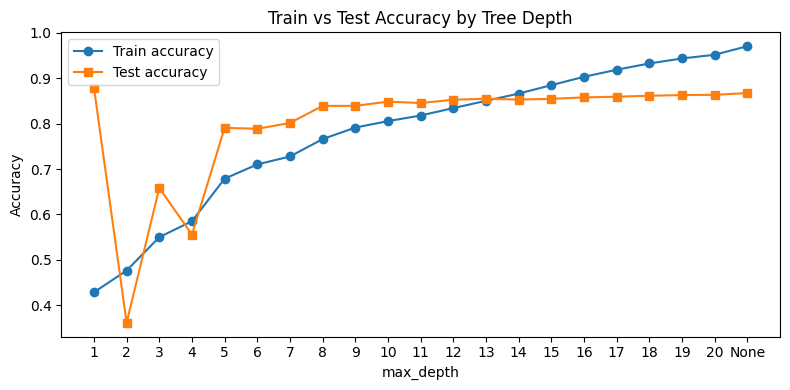

In [10]:

results = []
for depth in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, None]:
    clf = DecisionTreeClassifier(max_depth=depth,criterion='gini',min_samples_leaf=3,random_state=SEED)
    clf.fit(xTrain1, yTrain1)
    train_acc = accuracy_score(yTrain1, clf.predict(xTrain1))
    test_acc = accuracy_score(yTest, clf.predict(xTest))
    results.append({'max_depth': str(depth), 'train_acc': train_acc,'test_acc': test_acc})
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
# Plot
plt.figure(figsize=(8, 4))
plt.plot(results_df['max_depth'], results_df['train_acc'], marker='o',
label='Train accuracy')
plt.plot(results_df['max_depth'], results_df['test_acc'], marker='s',
label='Test accuracy')
plt.xlabel('max_depth'); plt.ylabel('Accuracy')
plt.title('Train vs Test Accuracy by Tree Depth')
plt.legend(); plt.tight_layout(); plt.show()

              precision    recall  f1-score   support

    No Fault       0.99      0.87      0.93     36950
 Minor Fault       0.33      0.72      0.45      3421
Severe Fault       0.58      0.67      0.62      2219

    accuracy                           0.85     42590
   macro avg       0.63      0.75      0.67     42590
weighted avg       0.92      0.85      0.87     42590



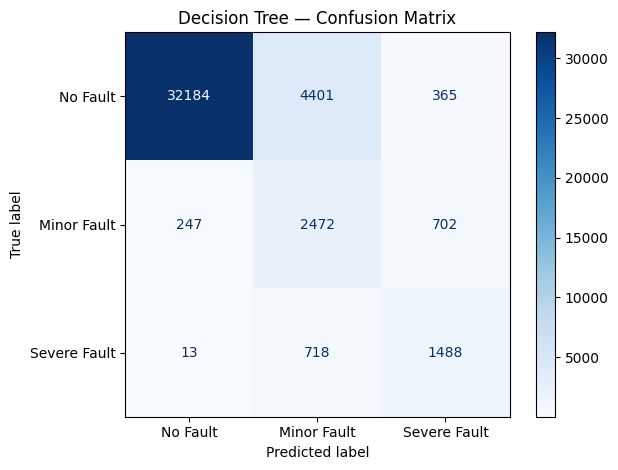

In [53]:
dt_best = DecisionTreeClassifier(max_depth=10, criterion='gini',min_samples_leaf=3,random_state=SEED)
dt_best.fit(xTrain1, yTrain1)
y_pred_best = dt_best.predict(xTest)
# Full classification report

print(classification_report(yTest, y_pred_best,
target_names=['No Fault', 'Minor Fault', 'Severe Fault']))
# Confusion matrix
cm = confusion_matrix(yTest, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
display_labels=['No Fault', 'Minor Fault', 'Severe Fault'])
disp.plot(cmap='Blues')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout(); plt.show()